## Imports

In [46]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import mesmer
import model
import model_analysis

import importlib
import matplotlib.pyplot as plt
import xarray as xr

import numpy as np

import cartopy.crs as ccrs
from scipy.stats import beta



## Load Data

In [47]:
is_local_data = True
Month_idx = 4
safe = False
start = None
end = None
depth = 3

In [48]:
raw_mrsol_for_mean = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=1)

raw_mrsol_for_var = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=2)

In [49]:
raw_mrsol_empirical_maximas = raw_mrsol_for_mean.max("time")

mrsol_maximas = raw_mrsol_empirical_maximas.copy(deep=True)
mrsol_maximas["mrsol"] = raw_mrsol_empirical_maximas["mrsol"] * 1.1 + 1e-5


In [50]:
tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=1)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=1)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=Month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=Month_idx)

raw_input_for_mean = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")

tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=2)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=2)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=Month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=Month_idx)

raw_input_for_var = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")

tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=3)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=3)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=Month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=Month_idx)

raw_input_for_test = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")


some explantions

In [51]:
def shape_target(ds, maximas):
    ds = ds/maximas
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx)
    return ds

In [52]:
def mask_stack_target(ds):
    masked_ds, chunk_mask, detail_mask= model.mask.mask_nonpositiv_height_chunks(ds.drop_vars("depth_bnds"))
    ds = mesmer.grid.stack_lat_lon(masked_ds)
    ds = ds.transpose("gridcell","time", "depth")
    return ds,chunk_mask, detail_mask, masked_ds

In [53]:
def shape_input(ds, chunk_mask):
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx)
    ds = model.mask.mask_mask(ds,chunk_mask)
    ds = mesmer.grid.stack_lat_lon(ds)
    return ds

    

In [54]:
#The chunk_mask schould all be the same, this is important that there are no shape problems in the regressions, you can test this with  
#(chunk_mask != chunk_mask_2).sum(),#(chunk_mask != chunk_mask_1).sum(),
#The chunk_mask is used, that the regression can predict a depth.size vector at each gridcell, the masks: detail_mask_mean, detail_mask_var and detail_mask_test are later used to determan which points are real predictions and witch where just placeholders to let the regression run smoothly.

### Linear Regression of the mean

In [55]:
mean_target = shape_target(raw_mrsol_for_mean, mrsol_maximas)
mean_target, chunk_mask, detail_mask, masked_target_unstacked = mask_stack_target(mean_target)
mean_target_da = mean_target.mrsol

In [56]:
mean_predictors = shape_input(raw_input_for_mean,chunk_mask)

In [57]:
LinReg_mean = model.stats._parallel_linear_regression.ParLinearRegression()

In [58]:
LinReg_mean.fit(predictors=mean_predictors, target=mean_target_da,location_dim="gridcell", regr_dim="time")

In [59]:
#LinReg_mean.params

### Compute Residuals for the variance

Hier wäre die meinung einen neuen Run zu verwenden, die frage ist ob sich die variance durch das fehlen des runs zu tief ausfällt. Overfitting korrektur mit 1/(1-param/n_samples)^2? (SPäter probieren)

In [60]:
var_target = shape_target(raw_mrsol_for_var, mrsol_maximas)
var_target, chunk_mask_var, detail_mask_var, masked_target_unstacked_var = mask_stack_target(var_target)


In [61]:
var_predictors = shape_input(raw_input_for_var,chunk_mask)

In [62]:
residuals = LinReg_mean.residuals(var_predictors, var_target)

### Linear Regression of the Variance

In [64]:
LinReg_variance = model.stats._parallel_linear_regression.ParLinearRegression()

In [65]:
LinReg_variance.fit(predictors=var_predictors, target=(residuals.residuals)**2,location_dim="gridcell", regr_dim="time")

### Predictor

In [91]:
#LinReg_mean.params

In [67]:
LinReg_mean, LinReg_variance

(<model.stats._parallel_linear_regression.ParLinearRegression at 0x7f0d60d58b90>,
 <model.stats._parallel_linear_regression.ParLinearRegression at 0x7f0d60f789d0>)

### Export Prameters

In [68]:
if False:
    model.save.save_params(LinReg_mean.params,LinReg_variance.params,var = "mrsol",scen= "historical", folder = "MPI-ESM1-2-LR/variations/Transformation_Distribution", name=f"dist_beta_transform_rel_month_idx= {month_idx}")

In [69]:
#model.shape_data.load_params(var = "mrsol",scen= "historical", folder = "MPI-ESM1-2-LR/variations/Transformation_Distribution", name=f"dist_beta_transform_rel_month_idx= {month_idx}")

### Example Emulation

In [70]:
test_predictors = shape_input(raw_input_for_test,chunk_mask)


In [71]:
test_mean_prediction_stacked = LinReg_mean.predict(test_predictors).transpose("gridcell","time", "depth")

In [72]:
test_var_prediction_stacked = LinReg_variance.predict(test_predictors).clip(min = 1e-32).transpose("gridcell","time", "depth")

### crps(s) Score

In [73]:
mean = test_mean_prediction_stacked.copy(deep=True)
var = test_var_prediction_stacked.copy(deep=True)

#todo precision parameter in guter Quelle finden
precision = (mean*(1-mean))/var-1

test_alpha_prediction_stacked = mean*precision
test_beta_prediction_stacked = (1-mean)*precision

In [74]:
maximas = model.mask.mask_mask(mrsol_maximas,chunk_mask)
maximas = mesmer.grid.stack_lat_lon(maximas).drop_vars("depth_bnds").transpose("gridcell","depth")


In [75]:
raw_test_target = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=3)
test_target = shape_target(raw_test_target, mrsol_maximas)
test_target, chunk_mask_test, detail_mask_test, masked_target_test = mask_stack_target(test_target)

In [77]:
crps_score_stacked, space_crps_score_stacked = model_analysis.crps_score.crps_beta_ensemble_score(test_alpha_prediction_stacked.isel(depth=slice(0,depth)).clip(min=1e-32), test_beta_prediction_stacked.isel(depth=slice(0,depth)).clip(min=1e-32),test_target.isel(depth=slice(0,depth)),transformation="rel",mrsol_maximas=maximas,ensemble_size=15)

for both of the scors we can calculate a crpss score against the time constant mean, for the score of the backtransposed data, we need to make a non-transposed target.

In [78]:

test_target_abs = test_target.copy(deep=True) 
test_target_abs["mrsol"] = test_target_abs["mrsol"] * maximas["mrsol"]


In [79]:
scores_stacked = model_analysis.crps_score.add_crpss_against_mean_ensemble_score(crps_score_stacked,test_target_abs) 

In [80]:
space_scores_stacked = model_analysis.crps_score.add_crpss_against_mean_ensemble_score(space_crps_score_stacked,test_target) 

To visualize the results we bring it back to the lat lon grid form. Ausserdem entnehmen wir die Stellen wieder, die mit threshholds aufgefüllt wurden

In [81]:
scores = mesmer.grid.unstack_lat_lon_and_align(scores_stacked,masked_target_unstacked.isel(depth=slice(0,depth)))
space_scores = mesmer.grid.unstack_lat_lon_and_align(space_scores_stacked,masked_target_unstacked.isel(depth=slice(0,depth)))

In [82]:
scores = model.mask.mask_mask(scores,detail_mask, "lon","lat", "depth")
space_scores = model.mask.mask_mask(space_scores,detail_mask, "lon","lat", "depth")

Globale Score übersicht

Text(0.5, 1.0, 'crpss_score against const mean')

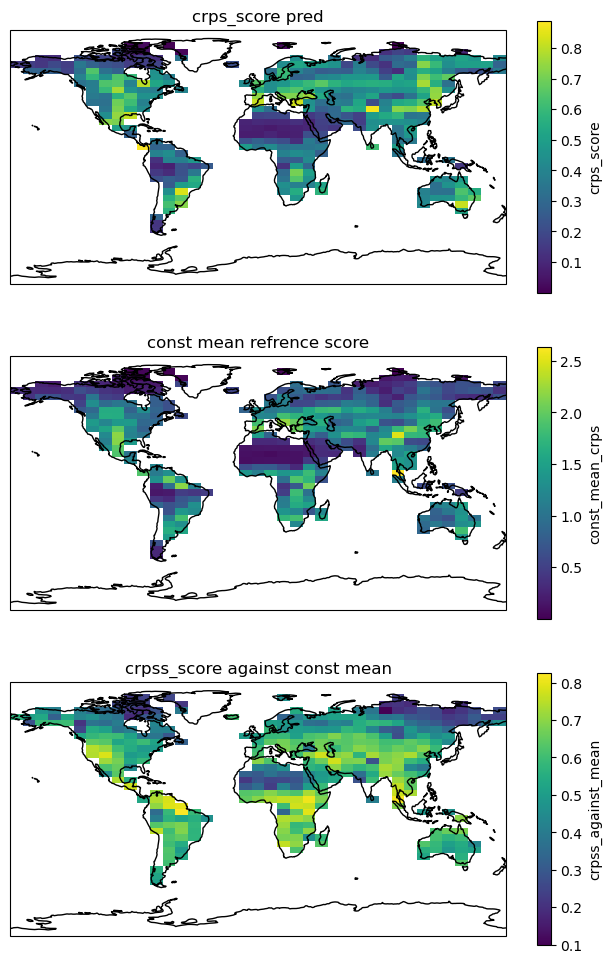

In [84]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=3,
    ncols=1,
    figsize=(8, 12)
)
depth = 0

da = scores.isel(depth=depth).mean("time").crps_score.clip(max=2)
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("crps_score pred")

da = scores.isel(depth=depth).mean("time").const_mean_crps
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("const mean refrence score")

da = scores.isel(depth=depth).mean("time").crpss_against_mean.clip(min=-1)
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("crpss_score against const mean")



Text(0.5, 1.0, 'space_crpss_score against const mean')

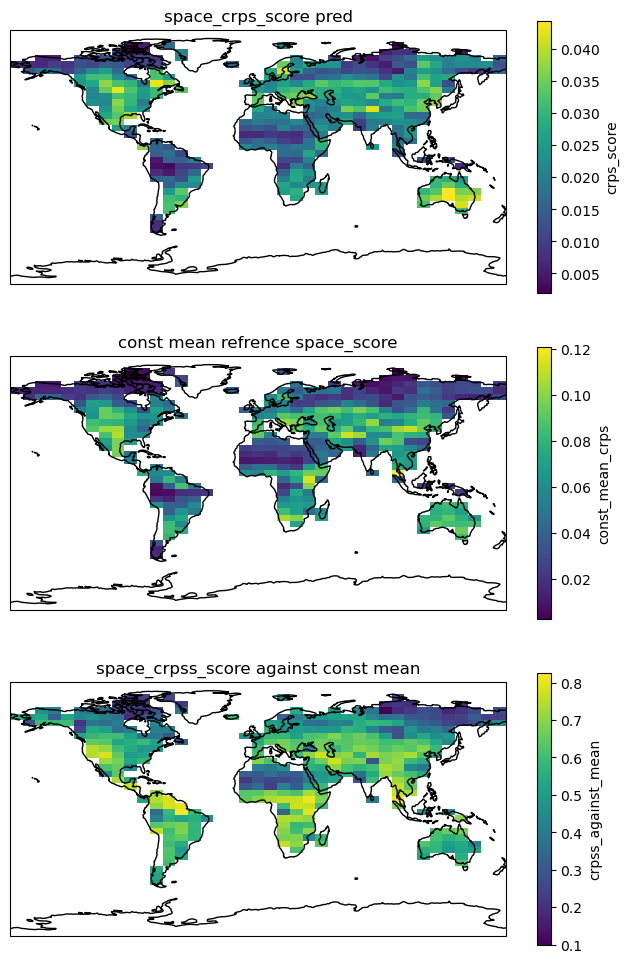

In [85]:
fig_global_space_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=3,
    ncols=1,
    figsize=(8, 12)
)

da = space_scores.isel(depth=0).mean("time").crps_score
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("space_crps_score pred")

da = space_scores.isel(depth=0).mean("time").const_mean_crps
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("const mean refrence space_score")

da = space_scores.isel(depth=0).mean("time").crpss_against_mean
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("space_crpss_score against const mean")



### Save results

In [90]:
if safe:
    model.save.save_crps_scores(space_scores, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/variations/Transformation_Distribution", name=f"dist_beta_transform_rel_month_idx= {Month_idx}",name_postfix="space_score")
    model.save.save_crps_scores(scores, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/variations/Transformation_Distribution", name=f"dist_beta_transform_rel_month_idx= {Month_idx}", name_postfix="")
    model.save.save_plot(fig_global_crpss, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/variations/Transformation_Distribution", name=f"dist_beta_transform_rel_month_idx= {Month_idx}")
    model.save.save_plot(fig_global_space_crpss, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/variations/Transformation_Distribution", name=f"dist_beta_transform_rel_month_idx= {Month_idx}")